In [8]:
import pickle
import time
import os
import re
import pprint
import numpy as np
from autqec.automorphisms   import *
from autqec.utils.qec       import *
from autqec.utils.qiskit    import *
from autqec.graph_auts      import *
from autqec.ZX_dualities    import *
from autqec.ZY_dualities    import *
from autqec.magma_interface import *
from autqec.code_embedding  import *

from magma_online import *

# 5-qubit perfect code [[5,1,3]]

$$
S = <XZZXI, IXZZX, XIXZZ, ZXIXZ>
$$

In [9]:
n_og = 5

n = 5
k = 1 
d = 3

stabs = ['XZZXI','IXZZX','XIXZZ','ZXIXZ']
H_symp = stabs_to_H_symp(stabs)
print(H_symp)

[[1 0 0 1 0 0 1 1 0 0]
 [0 1 0 0 1 0 0 1 1 0]
 [1 0 1 0 0 0 0 0 1 1]
 [0 1 0 1 0 1 0 0 0 1]]


In [10]:
H_symp_embedded = qec_embed_code(H_symp, embedding = 'all_weight_2').embed_mat()
n = H_symp_embedded.shape[1]//2
print(H_symp_embedded.shape)

(14, 30)


In [11]:
G, LX, LZ, D = compute_standard_form(H_symp_embedded)

In [12]:
command_file_name    = f"magma_commands_n{n}k{k}d{d}.txt"
output_file_name     = f"magma_output_n{n}k{k}d{d}.txt"
with open(output_file_name, "w") as output_file:
        pass

magma_obj = qec_code_auts_from_magma_with_intersection(n, k, d, H_symp_embedded)
# magma_obj = qec_code_auts_from_magma(n, k, d, H_symp_embedded)
magma_obj.run(fileroot='./',save_magma_commands=True)

run_magma_online_from_file(command_file_name)
code_auts_dict = parse_magma_output(output_file_name, magma_obj)

print('Aut Group Order: ', code_auts_dict['order'])
print('Time: ', code_auts_dict['time'])
print('No of aut gens: ', len(code_auts_dict['auts']))

Run the commands on MAGMA online calculator.
Copy and save output as 'magma_output_n15k1d3.txt'



Aut Group Order:  1440
Time:  0.63
No of aut gens:  7


In [6]:
auts = code_auts_dict['auts']
circuits = []
for num, aut in enumerate(auts):
    phys_act = circ_from_aut(H_symp_embedded,aut)        
    phys_circ, _ = phys_act.circ()
    log_act, circ = logical_circ_and_pauli_correct(H_symp_embedded,phys_circ).run()
    circuits.append((log_act,circ))

embedded physical circuit: [('S', 1), ('S', 2), ('S', 3), ('S', 4), ('S', 5), ('S', 6), ('S', 7), ('S', 8), ('S', 9), ('S', 10), ('S', 11), ('S', 12), ('S', 13), ('S', 14), ('S', 15)]
normal physical circuit:   [('S', 1), ('S', 2), ('S', 3), ('S', 4), ('S', 5), ('S', 1), ('S', 2), ('CZ', (1, 2)), ('S', 1), ('S', 3), ('CZ', (1, 3)), ('S', 1), ('S', 4), ('CZ', (1, 4)), ('S', 1), ('S', 5), ('CZ', (1, 5)), ('S', 2), ('S', 3), ('CZ', (2, 3)), ('S', 2), ('S', 4), ('CZ', (2, 4)), ('S', 2), ('S', 5), ('CZ', (2, 5)), ('S', 3), ('S', 4), ('CZ', (3, 4)), ('S', 3), ('S', 5), ('CZ', (3, 5)), ('S', 4), ('S', 5), ('CZ', (4, 5))]
logical action:            [('S', 1)]


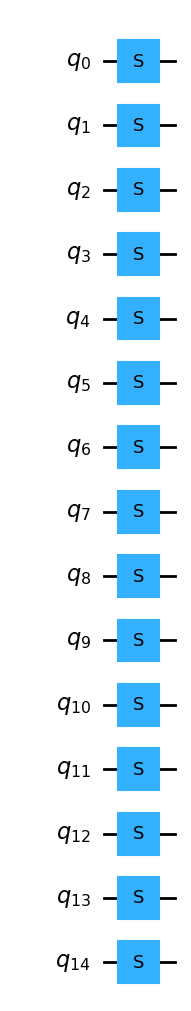

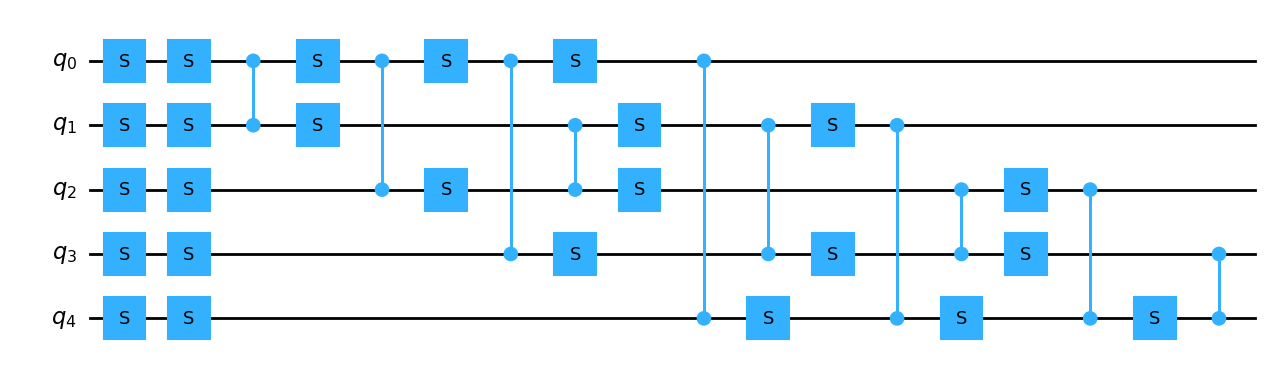

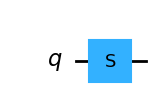



embedded physical circuit: [('Z', 1), ('Z', 2), ('Z', 3), ('Z', 4), ('Z', 15), ('S', 7), ('S', 9), ('S', 10), ('S', 12), ('SWAP', (9, 12)), ('SWAP', (8, 11)), ('SWAP', (7, 10)), ('SWAP', (1, 2))]
normal physical circuit:   [('Z', 1), ('Z', 2), ('Z', 3), ('Z', 4), ('S', 1), ('S', 3), ('CZ', (1, 3)), ('S', 1), ('S', 5), ('CZ', (1, 5)), ('S', 2), ('S', 3), ('CZ', (2, 3)), ('S', 2), ('S', 5), ('CZ', (2, 5)), ('CNOT', (5, 1)), ('CNOT', (5, 2)), ('SWAP', (1, 2)), ('CNOT', (5, 1)), ('CNOT', (5, 2)), ('CNOT', (4, 1)), ('CNOT', (4, 2)), ('SWAP', (1, 2)), ('CNOT', (4, 1)), ('CNOT', (4, 2)), ('CNOT', (3, 1)), ('CNOT', (3, 2)), ('SWAP', (1, 2)), ('CNOT', (3, 1)), ('CNOT', (3, 2)), ('SWAP', (1, 2))]
logical action:           COULD NOT FIND (circuit doesn't map to smaller space)


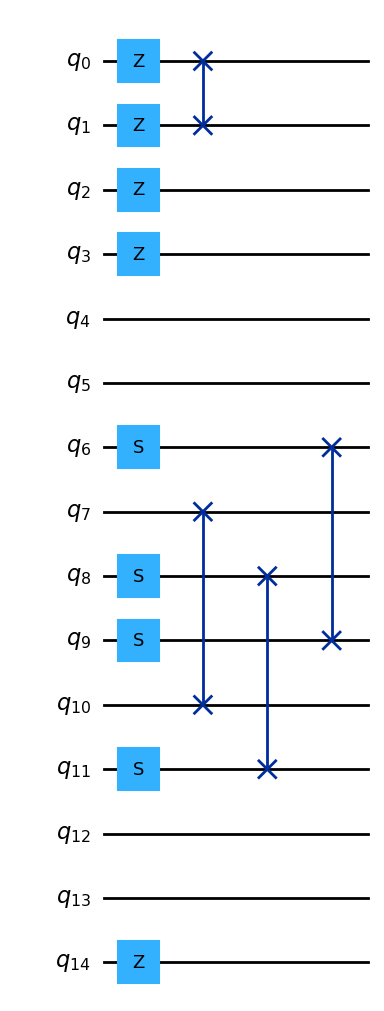

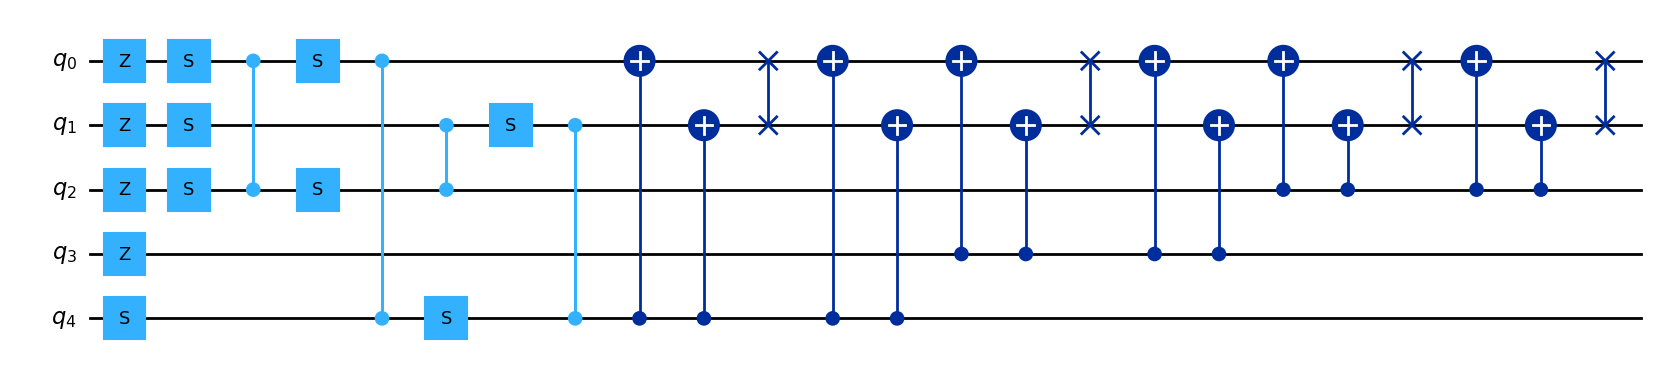



embedded physical circuit: [('Z', 1), ('Z', 2), ('Z', 3), ('Z', 4), ('Z', 15), ('S', 7), ('S', 9), ('S', 10), ('S', 12), ('SWAP', (13, 15)), ('SWAP', (10, 12)), ('SWAP', (7, 9)), ('SWAP', (3, 5))]
normal physical circuit:   [('Z', 1), ('Z', 2), ('Z', 3), ('Z', 4), ('S', 1), ('S', 3), ('CZ', (1, 3)), ('S', 1), ('S', 5), ('CZ', (1, 5)), ('S', 2), ('S', 3), ('CZ', (2, 3)), ('S', 2), ('S', 5), ('CZ', (2, 5)), ('CNOT', (4, 3)), ('CNOT', (5, 4)), ('SWAP', (3, 4)), ('CNOT', (4, 3)), ('CNOT', (5, 4)), ('CNOT', (3, 2)), ('CNOT', (5, 2)), ('SWAP', (2, 2)), ('CNOT', (3, 2)), ('CNOT', (5, 2)), ('CNOT', (3, 1)), ('CNOT', (5, 1)), ('SWAP', (1, 1)), ('CNOT', (3, 1)), ('CNOT', (5, 1)), ('SWAP', (3, 5))]
logical action:           COULD NOT FIND (circuit doesn't map to smaller space)


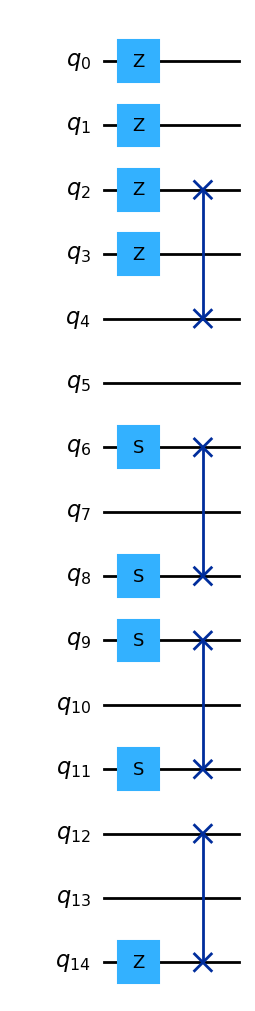

CircuitError: 'duplicate bit arguments'

In [14]:
embed_codespace_dict = {1: (1,2),
                        2: (1,3),
                        3: (1,4),
                        4: (1,5),
                        5: (2,3),
                        6: (2,4),
                        7: (2,5),
                        8: (3,4),
                        9: (3,5),
                        10: (4,5)}


for _, phys_circ in circuits:
    normal_circ  = embed_circ_to_normal_circ(phys_circ, n_og, embed_codespace_dict)
    try:
        log_act = logical_circ_and_pauli_correct(H_symp, normal_circ).run()[0]
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           ", log_act)
        display(construct_circuit(phys_circ, n).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        display(construct_circuit(log_act, k).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
    except:
        print("embedded physical circuit:", phys_circ)
        print("normal physical circuit:  ", normal_circ)
        print("logical action:           "+ "COULD NOT FIND (circuit doesn't map to smaller space)")
        display(construct_circuit(phys_circ, n).draw(output='mpl'))
        display(construct_circuit(normal_circ, n_og).draw(output='mpl'))
        print("\n"+80*"=" +"\n")
        continue